<a href="https://colab.research.google.com/github/kyliesutton/Kylie_Sutton_INFO4670_Spring2026/blob/main/kns0276_Assignment3_AssociationRuleMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [16]:
# write your answer here
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import matplotlib.pyplot as plt
import mlxtend as mlx
import networkx as nx

from google.colab import drive
drive.mount('/content/drive')
uploaded = "/content/drive/MyDrive/bread_basket.csv"

df = pd.read_csv(uploaded)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [17]:
# write your answer here
df.dtypes

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [18]:
# write your answer here
df.describe(include="all")

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2/4/2017,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

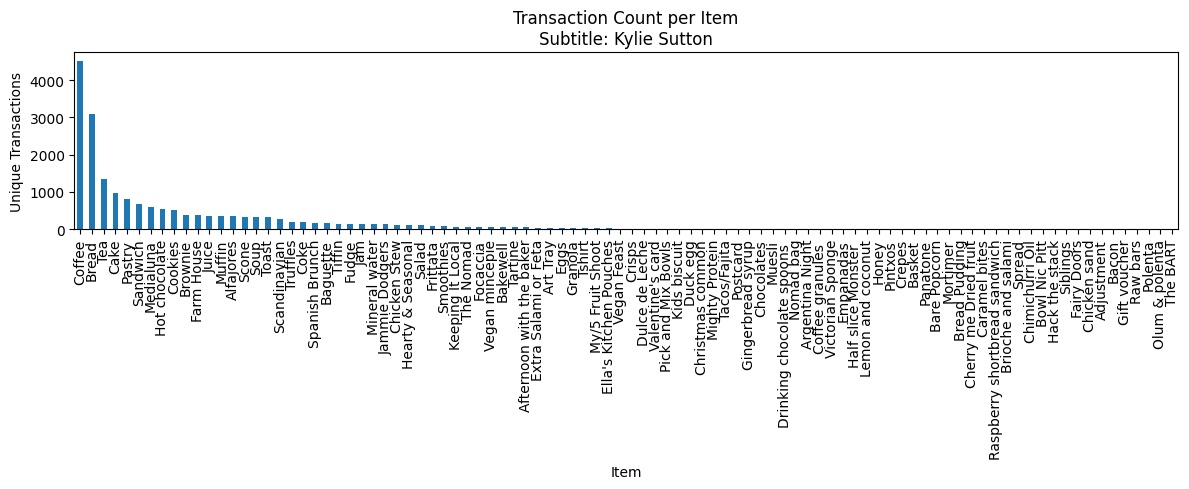

In [19]:
# c) Bar plot of transaction counts per item
subtitle = "Kylie Sutton"  # <-- EDIT THIS
item_counts = (df.groupby("item")["transaction"]
               .nunique() # <-- EDIT THIS
               .sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [20]:
# write your answer here
items_report = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]
counts = (df[df["item"].isin(items_report)]
          .groupby("item")["transaction"]
          .nunique()
          .reindex(items_report))
for item, count in counts.items():
  print(f"{item}: {count} unique transactions")

Coffee: 4528 unique transactions
Tea: 1350 unique transactions
Alfajores: 344 unique transactions
Juice: 365 unique transactions
Chicken Stew: 123 unique transactions


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [21]:
# write your answer here
from mlxtend.frequent_patterns import fpgrowth
basket = (df.assign(present=1).pivot_table(index="transaction", columns="item", values="present", aggfunc="max", fill_value=0))
basket = basket.astype(bool)
min_support = 0.01
frequent_itemsets = fpgrowth(basket, min_support=min_support, use_colnames=True)
frequent_itemsets["k"] = frequent_itemsets["itemsets"].apply(len)
print("total itemsets:", len(frequent_itemsets))
print("itemsets with k>=2:", (frequent_itemsets["k"] >= 2).sum())
frequent_itemsets.sort_values("support", ascending=False).head(15)


total itemsets: 61
itemsets with k>=2: 31


,support,itemsets,k
6,0.478394,(Coffee),1
0,0.327205,(Bread),1
9,0.142631,(Tea),1
16,0.103856,(Cake),1
30,0.090016,"(Bread, Coffee)",2
7,0.086107,(Pastry),1
18,0.071844,(Sandwich),1
8,0.061807,(Medialuna),1
2,0.058320,(Hot chocolate),1
46,0.054728,"(Cake, Coffee)",2


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [26]:
# write your answer here
from mlxtend.frequent_patterns import association_rules
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
  rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=i)
  print(f"min_threshold={i}: {len(rules)} rules")

min_threshold=0.1: 44 rules
min_threshold=0.2: 31 rules
min_threshold=0.3: 19 rules
min_threshold=0.4: 16 rules
min_threshold=0.5: 11 rules
min_threshold=0.6: 1 rules


In [25]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
sorted = rules.sort_values(["lift", "confidence", "support"], ascending=False)
sorted[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

,antecedents,consequents,support,confidence,lift
19,"(Tea, Coffee)",(Cake),0.010037,0.201271,1.937977
16,(Cake),(Tea),0.023772,0.228891,1.604781
28,(Toast),(Coffee),0.023666,0.704403,1.472431
21,(Sandwich),(Tea),0.014369,0.200000,1.402222
30,(Spanish Brunch),(Coffee),0.010882,0.598837,1.251766
10,(Medialuna),(Coffee),0.035182,0.569231,1.189878
6,(Pastry),(Coffee),0.047544,0.552147,1.154168
24,(Alfajores),(Coffee),0.019651,0.540698,1.130235
13,(Juice),(Coffee),0.020602,0.534247,1.116750
23,(Sandwich),(Coffee),0.038246,0.532353,1.112792


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

The rule {Coffee, Cake} => {Bread} was not generated using the selected support of 0.01 and confidence 0.2 thresholds. This means that the combination of Coffee and Cake does not also include Bread frequently enough to create a strong association.

Support: Since this rule was not generated the support for this combination fell below the minimum threshold.

Confidence: Due to this rule not meeting the minimum requirement, Bread is not strongly associated with Coffe and Cake.

Lift: With this rule was not among those generated, that means there is not a strong positive association between these items.

>